In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys

sys.path.append('src')

from matplotlib import pyplot as plt
plt.rcParams['figure.dpi'] = 75

In [2]:
import scanpy as sc
from scipy.sparse import csr_matrix

from anndata import AnnData
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

from src.cellina._spatial_utils import spatial_neighbors
from cellina import CellinaModel

import pandas as pd

In [3]:
# adata = sc.read_h5ad("../dsa/notebooks/synthetic_eval/synthetic_spatial_adata.h5ad")
# adata.var.index = adata.var['gene_name-new']
# domains_key = "region"
# labels_key = 'cell_type'

In [4]:
slide_id = 242

In [5]:
adata = sc.read(
    f"../../data/crc_wt_cosmx/crc_{slide_id}.h5ad",
    backup_url=f"https://zenodo.org/records/15574384/files/{slide_id}.h5ad?download=1"
)
# adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",
    
    "fib1": "Fibroblast",
    "fib2": "Fibroblast",
    
    "EC": "Endothelial",
    "SMC": "Smooth_muscle",
    
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",
    
    "TC": "T_cell",
    
    "mye1": "Myeloid",
    "mye2": "Myeloid",
    
    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
labels_key = 'coarse_type'
domains_key = 'typ'
adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

adata.obs[labels_key] = adata.obs[labels_key].astype('category')
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.layers['counts'] = adata.X.copy()

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [6]:
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=3000, subset=True)

In [7]:
adata.X

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 59175779 stored elements and shape (420694, 3000)>

In [8]:
n_neighbors = 50
# 10 is a good default option
spatial_neighbors(adata, bandwidth=np.inf, max_neighbours=n_neighbors, standardize=False)

### Spatial Microenvironment

In [9]:
import scipy.sparse as sp

def local_morans_I(adata, connectivities_key='spatial_connectivities',
                    sample_key=None, layer=None, use_rep=None,
                    key_added='local_morans_I'):
    """
    Local Moran's I per observation and feature.

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix.
    connectivities_key : str
        Key in ``adata.obsp`` for the spatial weights matrix.
    sample_key : str, optional
        Key in ``adata.obs`` identifying samples. When provided, local Moran's I
        is computed per sample and results are concatenated in original order.
    layer : str, optional
        Layer to use. ``None`` uses ``adata.X``.
    use_rep : str, optional
        Key in ``adata.obsm`` to use instead of X/layers.
    key_added : str
        Key under which results are stored in ``adata.layers`` (X/layers case)
        or ``adata.obsm`` (use_rep case).

    Returns
    -------
    np.ndarray
        Array of local Moran's I values (n_obs, n_features).
    """
    if sample_key is None:
        X = _get_X(adata, layer, use_rep)
        W = adata.obsp[connectivities_key]
        result = _local_morans_I(X, W)
        if use_rep is None:
            adata.layers[key_added] = result
        else:
            adata.obsm[key_added] = result
        return result

    samples = adata.obs[sample_key].cat.categories
    parts = []
    indices = []
    for s in tqdm(samples, desc="Computing local Moran's I"):
        mask = adata.obs[sample_key] == s
        adata_s = adata[mask]
        X_s = _get_X(adata_s, layer, use_rep)
        W_s = adata_s.obsp[connectivities_key]
        parts.append(_local_morans_I(X_s, W_s))
        indices.append(np.where(mask)[0])

    result = np.zeros((adata.n_obs, parts[0].shape[1]))
    for part, idx in zip(parts, indices):
        result[idx] = part

    if use_rep is None:
        adata.layers[key_added] = result
    else:
        adata.obsm[key_added] = result
    return result


def _local_morans_I(X, W):
    """
    Compute Local Moran's I_i for each location i and feature column.
    Note that this desparsifies the data matrix X, so use with caution for large sparse datasets.

    Parameters
    ----------
    X : array (n_samples, n_features)
    W : sparse or dense matrix (n_samples, n_samples)

    Returns
    -------
    L : array (n_samples, n_features)
        Each column is the Local Moran's vector for that feature.
    """

    # convert to sparse if needed
    if not sp.issparse(X):
        X = sp.csr_matrix(X)
    if not sp.issparse(W):
        W = sp.csr_matrix(W)
    
    n = X.shape[0]

    # row-standardise W
    W = W.tocsr()
    row_sums = np.array(W.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0
    W = sp.diags(1.0 / row_sums) @ W

    # compute mean for each feature
    X_mean = np.array(X.mean(axis=0)).flatten()

    # centre features (this densifies sparse matrices, unavoidable for Moran's I)
    Xc = X.toarray() - X_mean

    # denominator (scalar per feature)
    den = np.sum(Xc**2, axis=0) / n


    # spatial lag for each feature
    WX = W @ Xc     # (n × m)

    return (Xc / den) * WX

def _get_X(adata, layer=None, use_rep=None):
    """Extract data matrix from AnnData."""
    if use_rep is not None:
        return adata.obsm[use_rep]
    return adata.X if layer is None else adata.layers[layer]



In [ ]:
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers['morans'] = local_morans_I(adata)

In [ ]:
adata.layers['morans'].max()

77.78464578253481

In [ ]:
adata_crc = adata[adata.obs[domains_key]==f'{slide_id}_CRC']
sc.pp.pca(adata_crc, layer='morans', n_comps=50)
sc.pp.neighbors(adata_crc, use_rep='X_pca', n_neighbors=20)
sc.tl.leiden(adata_crc, resolution=0.05)

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/tmp/ipykernel_1517514/1116862724.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_crc, resolution=0.05)


In [ ]:
adata_crc.obs.loc[:,'microenvironment'] = [f"CRC{adata_crc.obs['leiden'].values[i]}" for i in range(len(adata_crc.obs))]

In [ ]:
adata.obs = adata.obs.merge(adata_crc.obs[['microenvironment']], left_index=True, right_index=True, how='left')

In [ ]:
# fill with domains_key if na
mask = adata.obs['microenvironment'].isna()
adata.obs['microenvironment'] = pd.Categorical(
    np.where(mask, adata.obs[domains_key].astype(str), adata.obs['microenvironment'].astype(str))
)

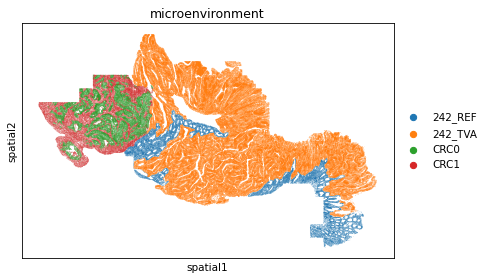

In [ ]:
sc.pl.spatial(adata, color='microenvironment', spot_size=100)

## DEGs

In [ ]:
import decoupler as dc

In [ ]:
progeny = dc.op.progeny(organism='human', top=500)

In [ ]:
pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col='microenvironment',
    groups_col=None,
    mode="sum",
    layer='counts'
)

In [ ]:
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)

In [ ]:
import pandas as pd

crc_envs = [m for m in pdata.obs['microenvironment'].unique() if 'CRC' in m]

df = pd.concat(
    [
        pd.Series(
            (pdata[pdata.obs['microenvironment'] == env].X - 
             pdata[pdata.obs['microenvironment'] == f'{slide_id}_REF'].X).flatten(),
            index=pdata.var_names,
            name=env
        )
        for env in crc_envs
    ],
    axis=1
).T

In [ ]:
enrichment, _ = dc.mt.ulm(df, net=progeny)

<Axes: >

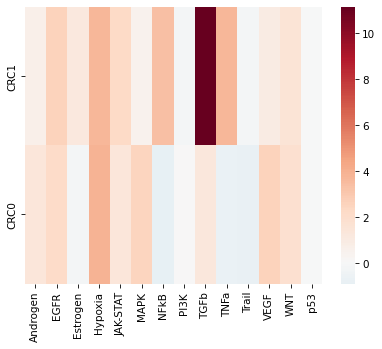

In [ ]:
import seaborn as sns
sns.heatmap(enrichment, cmap='RdBu_r', center=0)

### Train Model

In [ ]:
CellinaModel.setup_anndata(adata,
                           batch_key=None,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           layer='counts',
                           spatial_connectivities_key='spatial_connectivities'
                           )
model = CellinaModel(adata,
                     n_latent=20,
                    #  convolution_type='gat',
                     classifier_lambda=1,
                     discriminator_lambda=1,
                     n_layers=3,
                    #  link_prediction_weight=1, # NOTE Not sure if this is needed, nor if it works when combined with the other losses...
                     condition_on_intrinsic=False
                     )

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


In [ ]:
model.train(max_epochs=100,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=5,
            early_stopping_monitor='vae_loss_validation',
            train_size=0.9,
            validation_size=0.1,
            # default_root_dir='scvi_log/',
            plan_kwargs={'lr': 0.001,
                         'weight_decay': 0.0001,
                         'normalize_losses': True,
                        #  "scale_adversarial_loss": "normalized"
                         },
            enable_checkpointing=True,
            # callbacks=[
            #     SaveCheckpoint(monitor="validation_loss",
            #                    load_best_on_end=True,
            #                    dirpath=f'scvi_log/synthetic/',
            #                    filename='test1'),
            # ],
            batch_size=512,
            devices=[1]
            )

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


Training:   0%|          | 0/100 [00:00<?, ?it/s]

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 25425. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 25388. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 25288. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py

Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 598.271. Signaling Trainer to stop.


In [ ]:
list(model.history_.keys())

['validation_loss',
 'elbo_validation',
 'reconstruction_loss_validation',
 'kl_local_validation',
 'kl_global_validation',
 'vae_loss_validation',
 'classifier_loss_raw_validation',
 'classifier_loss_validation',
 'classifier_accuracy_validation',
 'fool_loss_raw_validation',
 'fool_loss_validation',
 'fool_accuracy_validation',
 'edge_prediction_loss_validation',
 'edge_prediction_accuracy_validation',
 'discriminator_loss_validation',
 'discriminator_accuracy_validation',
 'ema_vae_init',
 'ema_clf_init',
 'ema_fool_init',
 'ema_edge_init',
 'discriminator_loss_train',
 'discriminator_accuracy_train',
 'train_loss',
 'scale_classifier_train',
 'scale_fool_train',
 'scale_edge_train',
 'elbo_train',
 'reconstruction_loss_train',
 'kl_local_train',
 'kl_global_train',
 'vae_loss_train',
 'classifier_loss_raw_train',
 'classifier_loss_train',
 'classifier_accuracy_train',
 'fool_loss_raw_train',
 'fool_loss_train',
 'fool_accuracy_train',
 'edge_prediction_loss_train',
 'edge_predictio

<Axes: xlabel='epoch'>

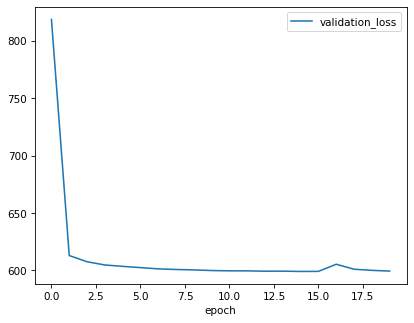

In [ ]:
model.history_['validation_loss'].plot()

<Axes: xlabel='epoch'>

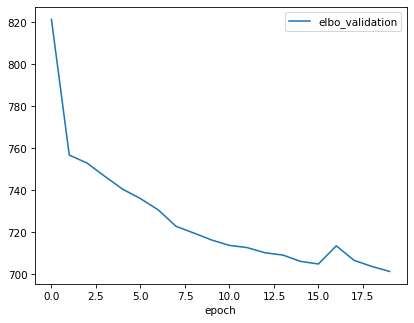

In [ ]:
model.history_['elbo_validation'].plot()

<Axes: xlabel='epoch'>

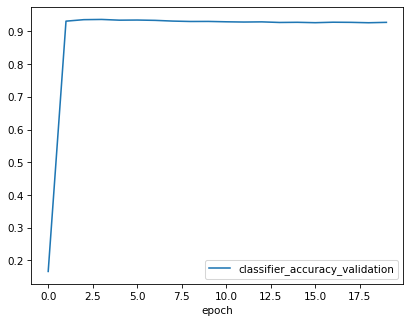

In [ ]:
model.history_['classifier_accuracy_validation'].plot()

<Axes: xlabel='epoch'>

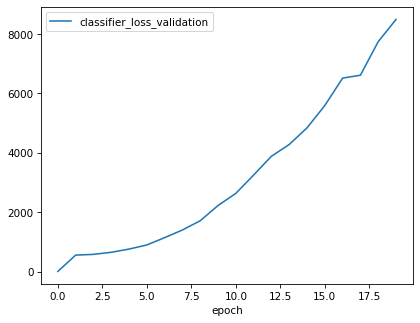

In [ ]:
model.history_['classifier_loss_validation'].plot()

<Axes: xlabel='epoch'>

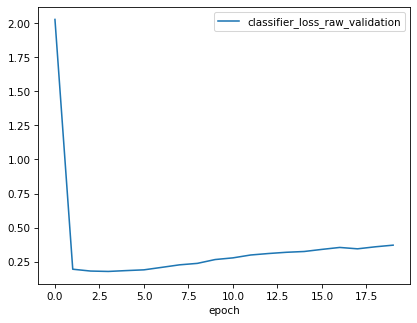

In [ ]:
model.history_['classifier_loss_raw_validation'].plot()

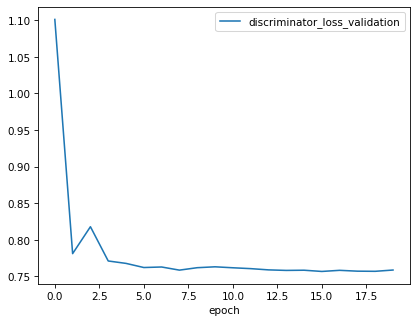

In [ ]:
if 'discriminator_loss_validation' in model.history_: # NOTE: only if discriminator_lambda > 0
    model.history_['discriminator_loss_validation'].plot()

In [ ]:
model.history_.keys()

dict_keys(['validation_loss', 'elbo_validation', 'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation', 'vae_loss_validation', 'classifier_loss_raw_validation', 'classifier_loss_validation', 'classifier_accuracy_validation', 'fool_loss_raw_validation', 'fool_loss_validation', 'fool_accuracy_validation', 'edge_prediction_loss_validation', 'edge_prediction_accuracy_validation', 'discriminator_loss_validation', 'discriminator_accuracy_validation', 'ema_vae_init', 'ema_clf_init', 'ema_fool_init', 'ema_edge_init', 'discriminator_loss_train', 'discriminator_accuracy_train', 'train_loss', 'scale_classifier_train', 'scale_fool_train', 'scale_edge_train', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'vae_loss_train', 'classifier_loss_raw_train', 'classifier_loss_train', 'classifier_accuracy_train', 'fool_loss_raw_train', 'fool_loss_train', 'fool_accuracy_train', 'edge_prediction_loss_train', 'edge_prediction_accuracy_train'])

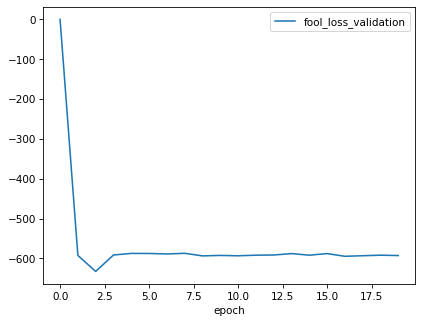

In [ ]:
if 'fool_loss_validation' in model.history_: # NOTE: only if discriminator_lambda > 0
    model.history_['fool_loss_validation'].plot()

<Axes: xlabel='epoch'>

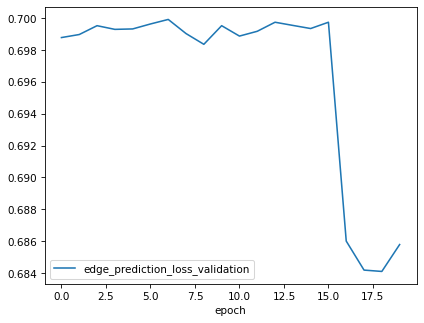

In [ ]:
model.history_['edge_prediction_loss_validation'].plot()

In [ ]:
model.history_.keys()

dict_keys(['validation_loss', 'elbo_validation', 'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation', 'vae_loss_validation', 'classifier_loss_raw_validation', 'classifier_loss_validation', 'classifier_accuracy_validation', 'fool_loss_raw_validation', 'fool_loss_validation', 'fool_accuracy_validation', 'edge_prediction_loss_validation', 'edge_prediction_accuracy_validation', 'discriminator_loss_validation', 'discriminator_accuracy_validation', 'ema_vae_init', 'ema_clf_init', 'ema_fool_init', 'ema_edge_init', 'discriminator_loss_train', 'discriminator_accuracy_train', 'train_loss', 'scale_classifier_train', 'scale_fool_train', 'scale_edge_train', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'vae_loss_train', 'classifier_loss_raw_train', 'classifier_loss_train', 'classifier_accuracy_train', 'fool_loss_raw_train', 'fool_loss_train', 'fool_accuracy_train', 'edge_prediction_loss_train', 'edge_prediction_accuracy_train'])

<Axes: xlabel='epoch'>

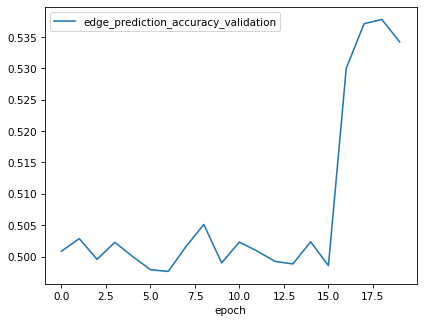

In [ ]:
model.history_['edge_prediction_accuracy_validation'].plot() # NOTE: makes sense that it's not very high, since the graph is very sparse and very large.

In [ ]:
adata.obsm['z'] = model.get_latent_representation(latent_key='z')

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


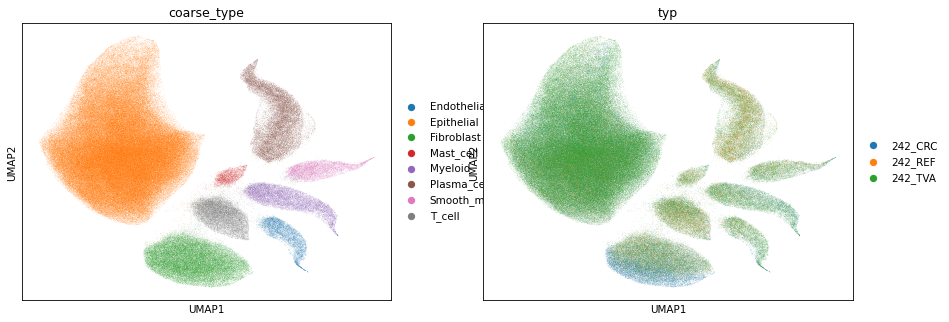

In [ ]:
sc.pp.neighbors(adata, use_rep='z')
sc.tl.umap(adata)
sc.pl.umap(adata, color=[labels_key, domains_key])

In [ ]:
adata.obsm['z'].max()

58.886852

In [ ]:
adata.obsm['s'] = model.get_latent_representation(latent_key='s')

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


In [ ]:
adata.obsm['s'].max()

8.69973

## CT

In [ ]:
ct_target = 'Endothelial'

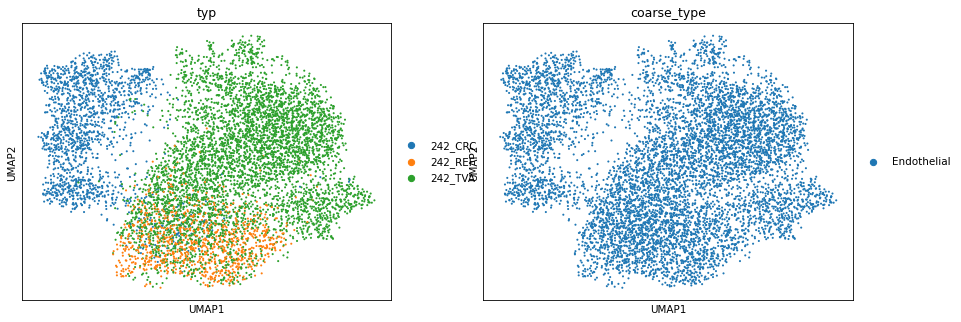

In [ ]:
fib_adata = adata[adata.obs[labels_key]==ct_target]
sc.pp.neighbors(fib_adata, use_rep='s')
sc.tl.umap(fib_adata)
sc.pl.umap(fib_adata, color=[domains_key, labels_key])

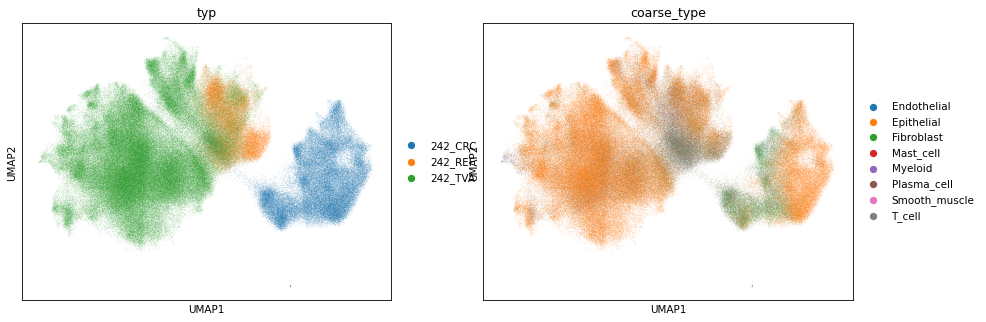

In [ ]:
sc.pp.neighbors(adata, use_rep='s')
sc.tl.umap(adata)
sc.pl.umap(adata, color=[domains_key, labels_key])

## Counterfactual

In [ ]:
# Counterfactual: fibroblasts in TVA with CRC neighbours
seed_mask = (adata.obs[labels_key] == ct_target) & (adata.obs[domains_key] == f'{slide_id}_REF')
nbr_mask  = adata.obs[domains_key] == f'{slide_id}_CRC'

seed_idx = np.where(seed_mask)[0]
nbr_idx  = np.where(nbr_mask)[0]

cf_s = model.get_counterfactual_latents(
    seed_idx, nbr_idx,
    n_neighbors_per_seed=10,
    latent_key='s',
    batch_size=512,
    give_mean=True
)

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


In [ ]:
import anndata as ad

# Subset real fibroblasts from each domain
fib_tva = adata[seed_mask].copy()
fib_crc = adata[(adata.obs[labels_key] == ct_target) & (adata.obs[domains_key] == f'{slide_id}_CRC')].copy()
fib_ref = adata[(adata.obs[labels_key] == ct_target) & (adata.obs[domains_key] == f'{slide_id}_REF')].copy()

# Build counterfactual anndata (same cells as fib_tva, but with cf spatial embedding)
fib_cf = fib_tva.copy()
fib_cf.obs[domains_key] = 'cf_REF→CRC'
fib_cf.obsm['s'] = cf_s

# Concatenate
combined = ad.concat([fib_tva, fib_crc, fib_ref, fib_cf])

# UMAP on s representation
sc.pp.neighbors(combined, use_rep='s')
sc.tl.umap(combined)

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


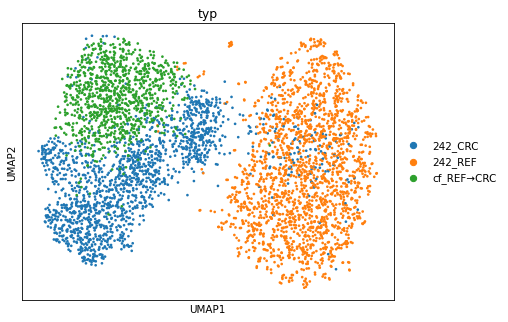

In [ ]:
sc.pl.umap(combined, color=[domains_key])

In [ ]:
adata.obs[domains_key].unique()

['242_CRC', '242_REF', '242_TVA']
Categories (3, object): ['242_CRC', '242_REF', '242_TVA']

In [ ]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd
import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


def _knn_masked_mean(kernel_matrix: torch.Tensor, k: int, exclude_self: bool) -> torch.Tensor:
    """
    Mean of a kernel matrix restricted to each row's top-k neighbours.

    Parameters
    ----------
    kernel_matrix
        Square (n, n) similarity matrix (higher = more similar).
    k
        Number of neighbours to retain per row.
    exclude_self
        If True, mask out the diagonal before selecting top-k.
    """
    mask = torch.zeros_like(kernel_matrix, dtype=torch.bool)
    for i in range(kernel_matrix.shape[0]):
        row = kernel_matrix[i].clone()
        if exclude_self:
            row[i] = -float("inf")
        k_eff = min(k, kernel_matrix.shape[1] - int(exclude_self))
        top_idx = torch.topk(row, k=k_eff).indices
        mask[i, top_idx] = True
    return kernel_matrix[mask].mean()


def _standard_edistance(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Standard energy distance between two sample sets.

    E(X, Y) = 2 * E[||x - y||] - E[||x - x'||] - E[||y - y'||]

    A value of 0 means the distributions are identical; larger values indicate
    greater distributional discrepancy.

    Parameters
    ----------
    X, Y
        2-D arrays of shape (n_cells, n_features).
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    Xt = torch.tensor(X, dtype=torch.float32, device=device)
    Yt = torch.tensor(Y, dtype=torch.float32, device=device)

    mean_dist_xy = torch.cdist(Xt, Yt, p=2).mean()
    mean_dist_xx = torch.cdist(Xt, Xt, p=2).mean()
    mean_dist_yy = torch.cdist(Yt, Yt, p=2).mean()

    return (2 * mean_dist_xy - mean_dist_xx - mean_dist_yy).item()


def _local_edistance(X: np.ndarray, Y: np.ndarray, k: int = 10) -> float:
    """
    Local energy distance restricted to each cell's k nearest neighbours.

    Uses negated Euclidean distances as a similarity kernel so that
    higher kernel values correspond to closer cells, making kNN selection
    consistent with _knn_masked_mean.

    Parameters
    ----------
    X, Y
        2-D arrays of shape (n_cells, n_features).
    k
        Number of nearest neighbours to consider per cell.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    Xt = torch.tensor(X, dtype=torch.float32, device=device)
    Yt = torch.tensor(Y, dtype=torch.float32, device=device)

    # Negated distances → larger value = closer neighbour
    K_xx = -torch.cdist(Xt, Xt, p=2)
    K_yy = -torch.cdist(Yt, Yt, p=2)
    K_xy = -torch.cdist(Xt, Yt, p=2)
    K_yx = K_xy.T

    mean_xx = _knn_masked_mean(K_xx, k, exclude_self=True)
    mean_yy = _knn_masked_mean(K_yy, k, exclude_self=True)
    mean_xy = _knn_masked_mean(K_xy, k, exclude_self=False)
    mean_yx = _knn_masked_mean(K_yx, k, exclude_self=False)

    return (mean_xx + mean_yy - mean_xy - mean_yx).item()


def _mixing_index(
    X_pred: np.ndarray,
    X_true: np.ndarray,
    n_clusters: int = 2,
    n_pcs: int = 50,
    random_state: int = 0,
) -> float:
    """
    Mixing index: fraction of predicted cells correctly co-clustered with true cells.

    Reduces dimensionality with PCA, clusters with KMeans, then computes how
    many predicted cells land in clusters that contain the expected proportion of
    true cells.  A value of 1 indicates perfect mixing; 0 indicates no mixing.

    Parameters
    ----------
    X_pred
        Expression matrix for counterfactual (predicted) cells, shape (n_pred, n_genes).
    X_true
        Expression matrix for real target cells, shape (n_true, n_genes).
    n_clusters
        Number of KMeans clusters.
    n_pcs
        Number of PCA components before clustering.
    random_state
        Random seed.
    """
    n_pred = X_pred.shape[0]
    n_true = X_true.shape[0]
    expected_proportion = n_pred / n_true

    # Joint PCA on stacked data
    X_combined = np.vstack([X_pred, X_true])
    n_pcs_eff = min(n_pcs, X_combined.shape[1], X_combined.shape[0] - 1)
    pca = PCA(n_components=n_pcs_eff, random_state=random_state)
    X_reduced = pca.fit_transform(X_combined)

    batch_labels = np.array(["pred"] * n_pred + ["true"] * n_true)

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    cluster_labels = kmeans.fit_predict(X_reduced)

    n_correctly_mixed = 0
    for cluster_id in range(n_clusters):
        in_cluster = cluster_labels == cluster_id
        n_pred_in = (batch_labels[in_cluster] == "pred").sum()
        n_true_in = (batch_labels[in_cluster] == "true").sum()
        n_correctly_mixed += min(n_pred_in, n_true_in * expected_proportion)

    return n_correctly_mixed / n_pred


# ---------------------------------------------------------------------------
# Internal bookkeeping helper
# ---------------------------------------------------------------------------

def _holdout_indices(
    adata,
    mask: np.ndarray,
    model=None,
    use_validation: bool = False,
) -> np.ndarray:
    """Return cell indices matching mask, restricted to holdout/validation cells."""
    if "is_holdout" in adata.obs.columns:
        holdout = adata.obs["is_holdout"].values.astype(bool)
        return np.where(mask & holdout)[0]
    if use_validation and model is not None and hasattr(model, "validation_indices_"):
        idx = np.where(mask)[0]
        val_set = set(model.validation_indices_)
        return idx[np.isin(idx, list(val_set))]
    return np.where(mask)[0]


# ---------------------------------------------------------------------------
# Main evaluation function
# ---------------------------------------------------------------------------

def compute_cf_logfc(
    model,
    adata,
    ref_domain,
    crc_domain,
    celltype_col: str = "coarse_type",
    domain_col: str = "typ",
    n_neighbors_per_seed: int = 10,
    batch_size: int = 512,
    min_cells: int = 200,
    use_validation: bool = False,
    seed: int = 0,
    top_n: int | None = None,
    local_edist_k: int = 10,
    mixing_n_clusters: int = 2,
    mixing_n_pcs: int = 50,
):
    """
    For each cell type present in both ref_domain and crc_domain, compute:
      - ref_denoised  : model-predicted expression for REF cells (real graph)
      - crc_denoised  : model-predicted expression for CRC cells (real graph)
      - crc_cf        : counterfactual expression for REF cells wired to CRC neighbours

    Log-fold-change metrics
    -----------------------
      real_logfc  = mean log1p(crc_denoised) − mean log1p(ref_denoised)
      cf_logfc    = mean log1p(crc_cf)       − mean log1p(ref_denoised)
      pearson_r / spearman_r between real_logfc and cf_logfc

    Precision (only when top_n is provided)
    ----------------------------------------
      Of the top_n genes ranked by |cf_logfc|, the fraction that overlap
      with the top_n genes ranked by |real_logfc|.

    Distributional metrics (crc_cf vs crc_denoised)
    ------------------------------------------------
      edist        : standard energy distance
      local_edist  : kNN-restricted energy distance (k = local_edist_k)
      mixing_index : fraction of CF cells correctly co-clustered with real CRC cells

    Parameters
    ----------
    model
        Trained CellinaModel.
    adata
        Registered AnnData.
    ref_domain
        Value of domain_col for the reference tissue (e.g. '242_REF').
    crc_domain
        Value of domain_col for the CRC tissue (e.g. '242_CRC').
    celltype_col
        obs column with cell-type labels.
    domain_col
        obs column with domain/tissue labels.
    n_neighbors_per_seed
        Donors to wire per seed cell (None = all CRC cells).
    batch_size
        Loader batch size.
    min_cells
        Skip cell types with fewer than this many cells in either domain.
    use_validation
        If True and no is_holdout column, restrict to model.validation_indices_.
    seed
        RNG seed for neighbour sampling.
    top_n
        If provided, restrict correlation metrics to the top_n genes ranked by
        absolute real_logfc.  logfcs dict still stores the full gene vectors.
    local_edist_k
        Number of nearest neighbours for local E-distance.
    mixing_n_clusters
        Number of KMeans clusters for mixing index.
    mixing_n_pcs
        Number of PCA components before KMeans clustering.

    Returns
    -------
    summary : pd.DataFrame
        One row per cell type with columns:
        cell_type, n_ref, n_crc, n_genes,
        pearson_r, pearson_p, spearman_r, spearman_p, precision,
        edist, local_edist, mixing_index.
    logfcs : dict
        {cell_type: {'real_logfc', 'cf_logfc', 'gene_names', 'top_n_mask'}}
    """
    rows, logfcs = [], {}

    for ct in sorted(adata.obs[celltype_col].unique()):
        ref_mask = (adata.obs[celltype_col] == ct) & (adata.obs[domain_col] == ref_domain)
        crc_mask = (adata.obs[celltype_col] == ct) & (adata.obs[domain_col] == crc_domain)

        ref_idx = _holdout_indices(adata, ref_mask, model=model, use_validation=use_validation)
        crc_idx = _holdout_indices(adata, crc_mask, model=model, use_validation=use_validation)

        if len(ref_idx) < min_cells or len(crc_idx) < min_cells:
            print(f"  skip {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")
            continue

        print(f"  {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")

        # ---- denoised expression for real graphs ----
        ref_denoised = model.get_normalized_expression(
            indices=ref_idx, batch_size=batch_size, library_size="latent"
        )
        crc_denoised = model.get_normalized_expression(
            indices=crc_idx, batch_size=batch_size, library_size="latent"
        )
        # ---- counterfactual: REF cells wired to CRC neighbours ----
        crc_cf = model.get_counterfactual_expression(
            ref_idx, crc_idx,
            n_neighbors_per_seed=n_neighbors_per_seed,
            batch_size=batch_size,
            seed=seed,
        )

        # ---- log-fold changes ----
        ref_mean    = np.log1p(ref_denoised.mean(0))
        crc_mean    = np.log1p(crc_denoised.mean(0))
        cf_mean     = np.log1p(crc_cf.mean(0))
        real_logfc  = crc_mean - ref_mean
        cf_logfc    = cf_mean  - ref_mean

        # ---- top-n gene selection ----
        top_n_mask = None
        precision  = float("nan")

        if top_n is not None:
            n_select = min(top_n, len(real_logfc))
            top_real_idx = set(np.argsort(np.abs(real_logfc))[-n_select:])
            top_cf_idx   = set(np.argsort(np.abs(cf_logfc))[-n_select:])

            top_n_mask = np.zeros(len(real_logfc), dtype=bool)
            top_n_mask[list(top_real_idx)] = True

            precision = len(top_real_idx & top_cf_idx) / n_select

            real_logfc_eval = real_logfc[top_n_mask]
            cf_logfc_eval   = cf_logfc[top_n_mask]
        else:
            real_logfc_eval = real_logfc
            cf_logfc_eval   = cf_logfc

        n_genes = int(top_n_mask.sum()) if top_n_mask is not None else len(real_logfc)

        # ---- correlation metrics ----
        pearson_r,  pearson_p  = pearsonr(real_logfc_eval, cf_logfc_eval)
        spearman_r, spearman_p = spearmanr(real_logfc_eval, cf_logfc_eval)

        # ---- distributional metrics (CF vs real CRC) ----
        # edist       = _standard_edistance(crc_cf, crc_denoised)
        # loc_edist   = _local_edistance(crc_cf, crc_denoised, k=local_edist_k)
        mix_idx     = _mixing_index(
            crc_cf, crc_denoised,
            n_clusters=mixing_n_clusters,
            n_pcs=mixing_n_pcs,
            random_state=seed,
        )

        rows.append(dict(
            cell_type=ct,
            n_ref=len(ref_idx),
            n_crc=len(crc_idx),
            n_genes=n_genes,
            pearson_r=pearson_r,
            pearson_p=pearson_p,
            spearman_r=spearman_r,
            spearman_p=spearman_p,
            precision=precision,
            # edist=edist,
            # local_edist=loc_edist,
            mixing_index=mix_idx,
        ))
        logfcs[ct] = dict(
            real_logfc=real_logfc,
            cf_logfc=cf_logfc,
            gene_names=adata.var_names.tolist(),
            top_n_mask=top_n_mask,
        )

    summary = (
        pd.DataFrame(rows)
        .sort_values("pearson_r", ascending=False)
        .reset_index(drop=True)
    )
    return summary, logfcs

In [ ]:
summary, logfcs = compute_cf_logfc(
    model, adata,
    ref_domain=f'{slide_id}_REF',
    crc_domain=f'{slide_id}_CRC',
    celltype_col=labels_key,
    domain_col=domains_key,
    n_neighbors_per_seed=20,
    batch_size=512,
    top_n=100
)

  Endothelial: ref=982, crc=1642


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  Epithelial: ref=19472, crc=53313


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


...

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  Smooth_muscle: ref=1571, crc=1672


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  T_cell: ref=4580, crc=3245


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


In [ ]:
print(summary)

       cell_type  n_ref  n_crc  n_genes  pearson_r     pearson_p  spearman_r  \
0     Epithelial  19472  53313      100   0.974115  0.000000e+00    0.837732   
1     Fibroblast   6100  22548      100   0.944733  0.000000e+00    0.753807   
2    Endothelial    982   1642      100   0.919102  2.003577e-41    0.755908   
3        Myeloid   1615   4147      100   0.917160  6.110222e-41    0.688521   
4    Plasma_cell   8887   2958      100   0.908868  5.343323e-39    0.760420   
5  Smooth_muscle   1571   1672      100   0.881914  8.945403e-34    0.696502   
6         T_cell   4580   3245      100   0.810342  1.758568e-24    0.642160   
7      Mast_cell    795    383      100   0.785634  3.730777e-22    0.505119   

     spearman_p  precision  mixing_index  
0  1.704326e-27       0.78      0.906855  
1  1.420061e-19       0.73      0.782530  
2  9.869406e-20       0.72      0.790110  
3  2.445923e-15       0.69      0.782583  
4  4.459900e-20       0.73      0.943088  
5  8.543224e-16      

In [ ]:
adata

AnnData object with n_obs × n_vars = 420694 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

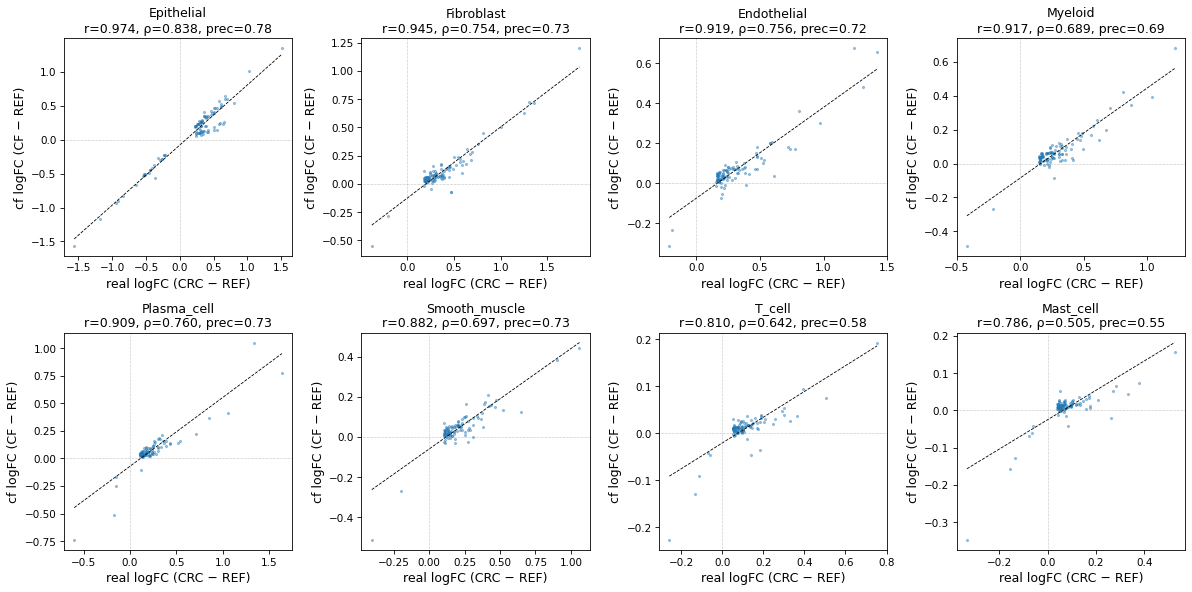

In [ ]:
n_cts = len(summary)
ncols = 4
nrows = (n_cts + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, (_, row) in enumerate(summary.iterrows()):
    ct = row["cell_type"]
    ax = axes[i]

    real = logfcs[ct]["real_logfc"]
    cf   = logfcs[ct]["cf_logfc"]
    mask = logfcs[ct]["top_n_mask"]
    if mask is not None:
        real, cf = real[mask], cf[mask]

    ax.scatter(real, cf, s=4, alpha=0.4)

    # Per-panel OLS fit line
    m, b = np.polyfit(real, cf, 1)
    x_lo, x_hi = real.min(), real.max()
    ax.plot([x_lo, x_hi], [m * x_lo + b, m * x_hi + b], color='k', lw=0.8, ls='--')

    # Zero crossings
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.axvline(0, color='grey', lw=0.5, ls=':')

    ax.set_xlabel('real logFC (CRC − REF)', fontsize=12)
    ax.set_ylabel('cf logFC (CF − REF)', fontsize=12)
    ax.set_title(
        f"{ct}\n"
        f"r={row['pearson_r']:.3f}, ρ={row['spearman_r']:.3f}, prec={row['precision']:.2f}",
        fontsize=12,
    )

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
summary_crc1, logfcs_crc1 = compute_cf_logfc(
    model, adata,
    ref_domain=f'{slide_id}_REF',
    crc_domain='CRC1',
    celltype_col=labels_key,
    domain_col='microenvironment',
    n_neighbors_per_seed=20,
    batch_size=512,
    top_n=100
)

  Endothelial: ref=982, crc=1588


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  Epithelial: ref=19472, crc=6210


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  Fibroblast: ref=6100, crc=22102


...

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  Smooth_muscle: ref=1571, crc=1647


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  T_cell: ref=4580, crc=3041


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


In [ ]:
from scipy.stats import pearsonr, spearmanr

for ct in summary_crc1['cell_type']:
    print(f"{ct}:")
    print(f" Average: {pearsonr(logfcs[ct]['real_logfc'], logfcs_crc1[ct]['cf_logfc'])}")
    print(f" Within: {spearmanr(logfcs_crc1[ct]['real_logfc'], logfcs_crc1[ct]['cf_logfc'])}")

Fibroblast:
 Average: PearsonRResult(statistic=0.8805346980657849, pvalue=0.0)
 Within: SignificanceResult(statistic=0.5868108525997403, pvalue=3.882780148577709e-277)
Epithelial:
 Average: PearsonRResult(statistic=0.8821106126791675, pvalue=0.0)
 Within: SignificanceResult(statistic=0.7391190413175733, pvalue=0.0)
Myeloid:
 Average: PearsonRResult(statistic=0.8593358107941401, pvalue=0.0)
 Within: SignificanceResult(statistic=0.6200413711157078, pvalue=2.986755e-318)
Endothelial:
 Average: PearsonRResult(statistic=0.8664471145673942, pvalue=0.0)
 Within: SignificanceResult(statistic=0.6248451843855588, pvalue=0.0)
Plasma_cell:
 Average: PearsonRResult(statistic=0.8795513607773118, pvalue=0.0)
 Within: SignificanceResult(statistic=0.8001310151701564, pvalue=0.0)
Smooth_muscle:
 Average: PearsonRResult(statistic=0.8225699511811404, pvalue=0.0)
 Within: SignificanceResult(statistic=0.6301640131993529, pvalue=0.0)
T_cell:
 Average: PearsonRResult(statistic=0.7063979092947605, pvalue=0.0)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

plt.rcParams['figure.dpi'] = 150

# ── 1. collect average baseline (already have: summary, logfcs) ─────────────

# ── 2. collect per-subtype summaries ────────────────────────────────────────
crc_subtypes = sorted(
    m for m in adata.obs['microenvironment'].cat.categories
    if str(m).startswith('CRC')
)

summaries_within = {}
for subtype in crc_subtypes:
    s, _ = compute_cf_logfc(
        model, adata,
        ref_domain=f'{slide_id}_REF',
        crc_domain=subtype,
        celltype_col=labels_key,
        domain_col='microenvironment',
        n_neighbors_per_seed=20,
        batch_size=512,
        top_n=100,
    )
    summaries_within[subtype] = s.set_index('cell_type')

summary_avg = summary.set_index('cell_type')


  skip Endothelial: ref=982, crc=54
  Epithelial: ref=19472, crc=47103


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  Fibroblast: ref=6100, crc=446


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  skip Mast_cell: ref=795, crc=29
  Myeloid: ref=1615, crc=222


...

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  Smooth_muscle: ref=1571, crc=1647


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  T_cell: ref=4580, crc=3041


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


/tmp/ipykernel_1127819/2282030273.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', len(crc_subtypes))


Text(0.5, 1.01, 'Counterfactual accuracy: average vs within-subtype CRC')

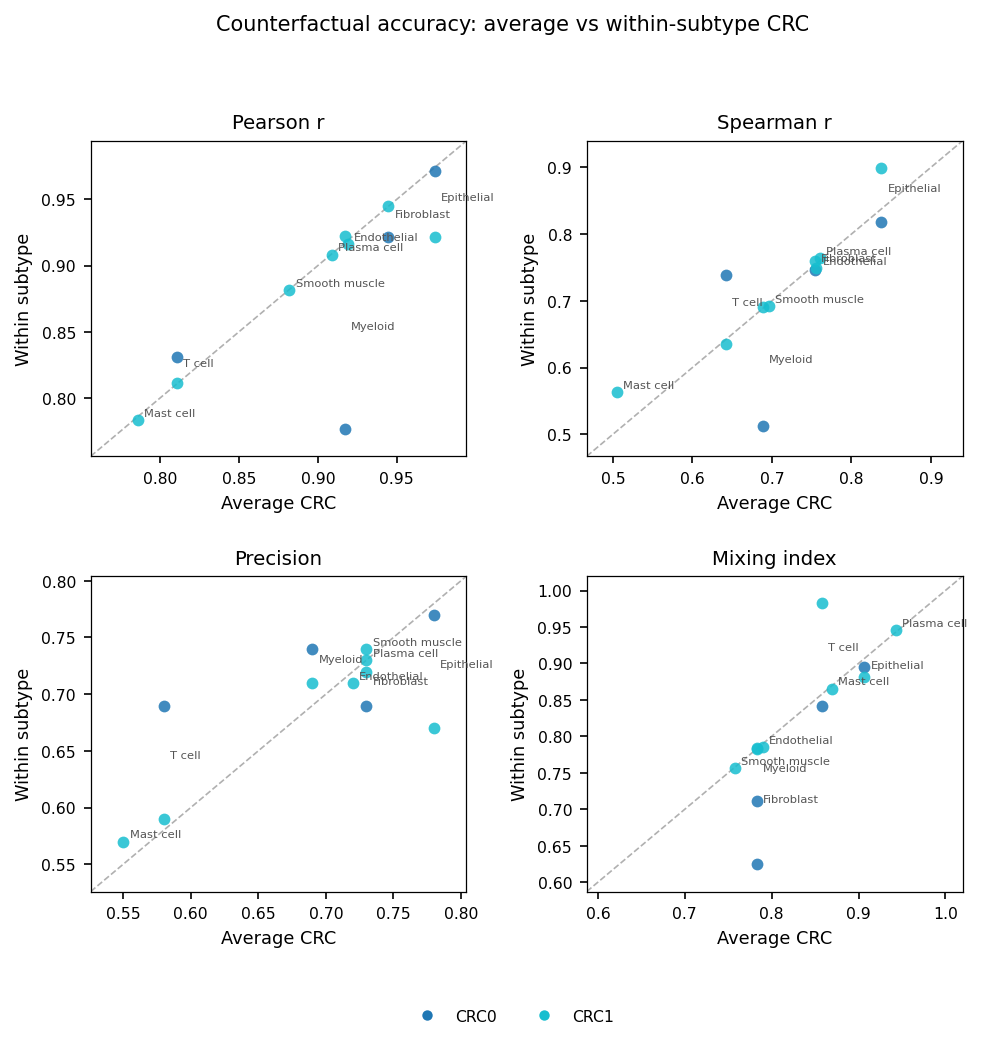

In [ ]:
metrics = ['pearson_r', 'spearman_r', 'precision', 'mixing_index']
metric_labels = {
    'pearson_r':    'Pearson r',
    'spearman_r':   'Spearman r',
    'precision':    'Precision',
    'mixing_index': 'Mixing index',
}

cmap   = plt.cm.get_cmap('tab10', len(crc_subtypes))
colors = {s: cmap(i) for i, s in enumerate(crc_subtypes)}

fig, axes = plt.subplots(2, 2, figsize=(7.5, 6.5))
fig.subplots_adjust(hspace=0.38, wspace=0.32)

for ax, metric in zip(axes.flat, metrics):
    x_avg = summary_avg[metric]

    for subtype, s_w in summaries_within.items():
        common = x_avg.index.intersection(s_w.index)
        x = x_avg.loc[common].values
        y = s_w.loc[common, metric].values
        ax.scatter(x, y, color=colors[subtype], s=32, alpha=0.85,
                   linewidths=0, zorder=3, label=subtype)

    # diagonal
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    pad = (hi - lo) * 0.05
    lo, hi = lo - pad, hi + pad
    ax.plot([lo, hi], [lo, hi], color='#b0b0b0', lw=0.8, ls='--', zorder=0)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    # cell-type labels — placed at (avg_x, mean_within_y) to avoid clutter
    common_all = x_avg.index
    for ct in common_all:
        y_vals = [
            s_w.loc[ct, metric]
            for s_w in summaries_within.values()
            if ct in s_w.index
        ]
        if not y_vals:
            continue
        ax.annotate(
            ct.replace('_', ' '),
            xy=(x_avg.loc[ct], np.mean(y_vals)),
            fontsize=5.5, color='#555',
            xytext=(3, 2), textcoords='offset points',
        )

    ax.set_xlabel('Average CRC', fontsize=8.5, labelpad=4)
    ax.set_ylabel('Within subtype', fontsize=8.5, labelpad=4)
    ax.set_title(metric_labels[metric], fontsize=9.5, pad=6)
    ax.tick_params(labelsize=7.5)
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

# shared legend below figure
handles = [
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor=colors[s],
                  markersize=6, label=s)
    for s in crc_subtypes
]
fig.legend(
    handles=handles,
    loc='lower center',
    ncol=len(crc_subtypes),
    fontsize=7.5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.04),
)

fig.suptitle(
    'Counterfactual accuracy: average vs within-subtype CRC',
    fontsize=10, y=1.01,
)

# plt.savefig('cf_accuracy_avg_vs_within.pdf', bbox_inches='tight', dpi=150)
# plt.show()

In [ ]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# ── 1. identify CRC subtypes ─────────────────────────────────────────────────
crc_subtypes = sorted(
    m for m in adata.obs['microenvironment'].cat.categories
    if str(m).startswith('CRC')
)

# ── 2. run compute_cf_logfc for each subtype ─────────────────────────────────
logfcs_within = {}   # subtype -> logfcs dict (keyed by cell type)
for subtype in crc_subtypes:
    _, lf = compute_cf_logfc(
        model, adata,
        ref_domain=f'{slide_id}_REF',
        crc_domain=subtype,
        celltype_col=labels_key,
        domain_col='microenvironment',
        n_neighbors_per_seed=20,
        batch_size=512,
        top_n=100,
    )
    logfcs_within[subtype] = lf

# logfcs is the pooled average CRC run (already computed, domain_col=domains_key)

# ── 3. collect per-cell-type, per-subtype correlations ───────────────────────
records = []
for subtype, lf_w in logfcs_within.items():
    cell_types = list(lf_w.keys())
    for ct in cell_types:
        real  = lf_w[ct]['real_logfc']          # same real in both comparisons
        cf_w  = lf_w[ct]['cf_logfc']            # subtype-specific prediction
        cf_av = logfcs[ct]['cf_logfc']          # pooled CRC prediction

        r_within,  _ = pearsonr(real, cf_w)
        r_avg,     _ = pearsonr(real, cf_av)
        rho_within,_ = spearmanr(real, cf_w)
        rho_avg,   _ = spearmanr(real, cf_av)

        records.append(dict(
            subtype=subtype, cell_type=ct,
            pearson_within=r_within,   pearson_avg=r_avg,
            spearman_within=rho_within, spearman_avg=rho_avg,
        ))

import pandas as pd
df = pd.DataFrame(records)


  skip Endothelial: ref=982, crc=54
  Epithelial: ref=19472, crc=47103


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  Fibroblast: ref=6100, crc=446


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  skip Mast_cell: ref=795, crc=29
  Myeloid: ref=1615, crc=222


...

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  Smooth_muscle: ref=1571, crc=1647


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  T_cell: ref=4580, crc=3041


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


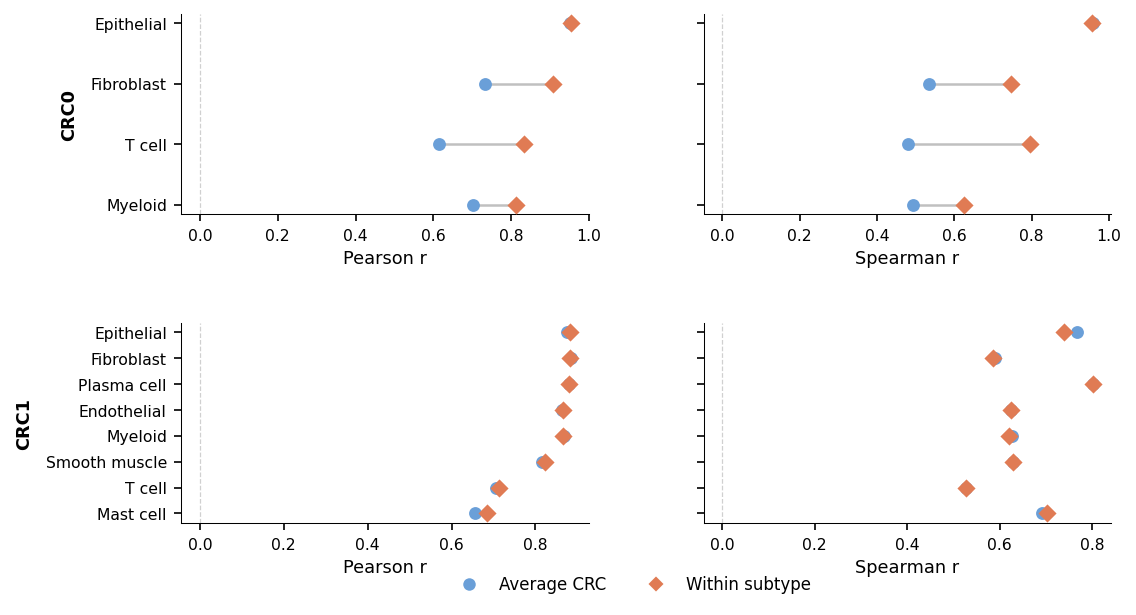

In [ ]:
fig, axes = plt.subplots(
    len(crc_subtypes), 2,
    figsize=(8, 2.2 * len(crc_subtypes)),
    sharey='row',
)
fig.subplots_adjust(hspace=0.55, wspace=0.28)

metrics = [
    ('pearson_avg',  'pearson_within',  'Pearson r'),
    ('spearman_avg', 'spearman_within', 'Spearman r'),
]

for row, subtype in enumerate(crc_subtypes):
    grp = df[df['subtype'] == subtype].copy()
    # sort cell types by Within score (Pearson) so ordering is meaningful
    grp = grp.sort_values('pearson_within', ascending=True)
    cell_types = grp['cell_type'].tolist()
    yticks = np.arange(len(cell_types))

    for col, (x_avg, x_within, metric_label) in enumerate(metrics):
        ax = axes[row, col]

        avg_vals    = grp[x_avg].values
        within_vals = grp[x_within].values

        # connecting lines
        for i, (a, w) in enumerate(zip(avg_vals, within_vals)):
            ax.hlines(i, a, w, color='#c0c0c0', lw=1.2, zorder=1)

        # dots
        ax.scatter(avg_vals,    yticks, color='#6a9fd8', s=38, zorder=3,
                   label='Average CRC',   linewidths=0)
        ax.scatter(within_vals, yticks, color='#e07b54', s=38, zorder=3,
                   label='Within subtype', linewidths=0, marker='D')

        ax.axvline(0, color='#d0d0d0', lw=0.6, ls='--', zorder=0)

        ax.set_yticks(yticks)
        ax.set_yticklabels(
            [ct.replace('_', ' ') for ct in cell_types], fontsize=7.5
        )
        ax.set_xlabel(metric_label, fontsize=8.5, labelpad=3)
        ax.tick_params(axis='x', labelsize=7.5)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if col == 0:
            ax.set_ylabel(subtype, fontsize=8.5, labelpad=6, fontweight='bold')

# shared legend
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#6a9fd8',
           markersize=7, label='Average CRC'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#e07b54',
           markersize=6, label='Within subtype'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))


plt.show()

In [ ]:
stop

NameError: name 'stop' is not defined

In [ ]:
def spatial_coherence_score(X, labels, k=5):
    X = np.asarray(X)
    labels = np.asarray(labels)

    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    _, indices = nbrs.kneighbors(X)

    # exclude each point itself (indices[:,0])
    indices = indices[:, 1:]
    
    same_cluster_counts = np.sum(labels[indices] == labels[:, None], axis=1)
    scs = np.mean(same_cluster_counts / k)
    return scs


In [ ]:
# Nearest Neighbours and Leiden Clustering
sc.pp.neighbors(adata, use_rep='s')
sc.tl.umap(adata, neighbors_key='neighbors')

KeyError: 'Could not find key leiden_s in .var_names or .obs.columns.'

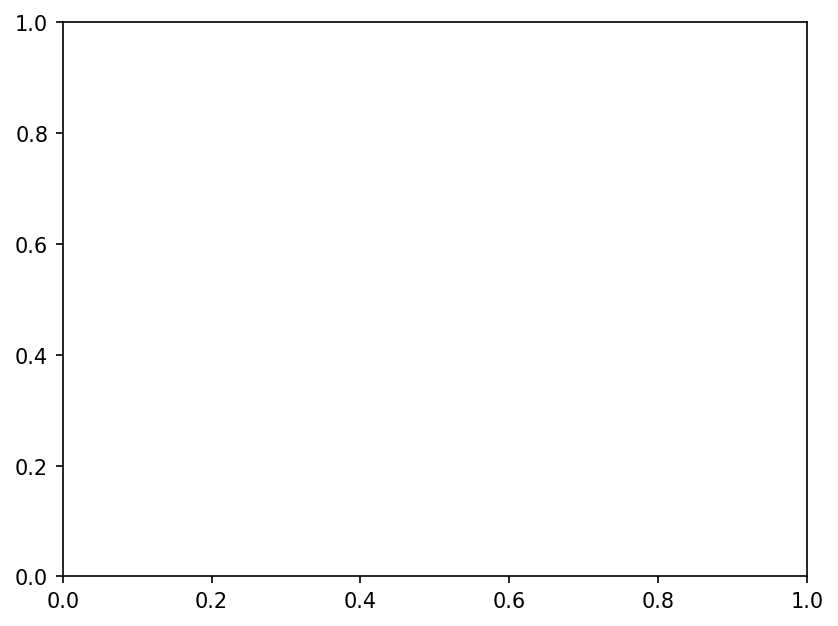

In [ ]:
sc.pl.spatial(adata, color=['leiden_s'], spot_size=50)

In [ ]:

sc.tl.leiden(adata, key_added='leiden_s', resolution=0.4)

spatial_coherence_score(adata.obsm['spatial'], adata.obs['leiden_s'], k=n_neighbors) # NOTE: most sensible metric imho
# NOTE: worse than when using spatial_x

0.955180012075285

In [ ]:
def compute_spatial_metrics(adata, label_key: str, coord_key: str = 'spatial', exclude_labels=None) -> float:
    from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, silhouette_samples
    import pandas as pd
    from scipy.spatial.distance import pdist, squareform

    adata.obs[label_key] = adata.obs[label_key].astype('category')
    
    if exclude_labels is not None:
        mask = ~adata.obs[label_key].isin(exclude_labels)
        ad = adata[mask].copy()
    else:
        ad = adata

    labels = ad.obs[label_key].cat.codes.values
    spatial_coords = ad.obsm[coord_key]

    mean_asw = silhouette_score(X=spatial_coords, labels=labels, metric='euclidean')
    db_score = davies_bouldin_score(X=spatial_coords, labels=labels)
    ch_score = calinski_harabasz_score(X=spatial_coords, labels=labels)
    
    samples_asw = silhouette_samples(X=spatial_coords, labels=labels, metric='euclidean')
    
    df = pd.DataFrame(index=ad.obs_names, data={f'spatial_asw_{label_key}': samples_asw})
    asw_by_label = df.groupby(ad.obs[label_key])[f'spatial_asw_{label_key}'].mean().round(3)
    asw_by_label.index.name = label_key
    asw_by_label = asw_by_label.to_dict()
    
    global_scores = {
        'asw ↑': round(mean_asw, 3),
        'db_score ↓': round(db_score, 3),
        'ch_score ↑': round(ch_score, 3)
    }
    
    return global_scores, asw_by_label

In [ ]:
# compute_spatial_metrics(adata, label_key='leiden_s', coord_key='spatial') # NOTE: takes forever